# Raw ORB: development experiment and evaluation

This notebook is the complete development interface for raw ORB feature detection and matching. It verifies the manifest, runs or reloads all 139 development records, evaluates detections against XML ground truth annotations, and visualises keypoints, feature matches, class performance, runtime, and representative sample detections. In adherence to the project protocol, all processing remains strictly in its **raw form** without morphology, clustering, or region merging.

In [10]:
import json
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / 'data' / 'dataset_split.csv').is_file()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from algorithms.common import load_image, preprocess_pair
from algorithms.evaluation import box_iou, evaluate_boxes, parse_voc_boxes
from algorithms.orb import detect_orb, extract_raw_boxes_from_points
from scripts.development.run_orb_development import (
    evaluate_records,
    load_development_rows,
    summarise,
    write_results,
)

plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 30)

## 1. Development baseline configuration

Development is used to implement and debug the raw ORB baseline and inspect feature matching behavior on aligned PCBs. In accordance with project rules, no morphological refinement, blur, or contour merging is applied.

In [11]:
MANIFEST_PATH = PROJECT_ROOT / 'data' / 'dataset_split.csv'
RESULTS_PATH = PROJECT_ROOT / 'outputs' / 'metrics' / 'orb_development.csv'
SUMMARY_PATH = PROJECT_ROOT / 'outputs' / 'metrics' / 'orb_development_summary.json'
BOXES_DIR = PROJECT_ROOT / 'outputs' / 'metrics' / 'orb_development_boxes'
IOU_THRESHOLD = 0.50
RUN_DEVELOPMENT = False  # Set True to recompute all 139 full-resolution images.

development_baseline = {
    'input': 'aligned reference and defective image pair',
    'shared_preprocessing': 'dimension validation and grayscale conversion',
    'feature_detector': 'cv2.ORB_create(nfeatures=5000, scaleFactor=1.2, nlevels=8)',
    'descriptor_matcher': 'cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)',
    'inconsistency_rule': 'spatial disparity > 15px OR Hamming distance > 60 OR unmatched keypoints',
    'bounding_box_generation': 'raw fixed-radius box [x - 35, y - 35, x + 35, y + 35] per defect keypoint',
    'post_processing': 'none (no clustering, no dilation, no merging)',
    'evaluation_iou': IOU_THRESHOLD,
}
pd.Series(development_baseline, name='setting').to_frame()

,setting
input,aligned reference and defective image pair
shared_preprocessing,dimension validation and grayscale conversion
feature_detector,"cv2.ORB_create(nfeatures=5000, scaleFactor=1.2..."
descriptor_matcher,"cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)"
inconsistency_rule,spatial disparity > 15px OR Hamming distance >...
bounding_box_generation,"raw fixed-radius box [x - 35, y - 35, x + 35, ..."
post_processing,"none (no clustering, no dilation, no merging)"
evaluation_iou,0.5


## 2. Manifest and development-split verification

,images
split,
development,139
validation,139
test,415


,development_images
defect_class,
missing_hole,23
mouse_bite,23
open_circuit,24
short_circuit,23
spur,23
spurious_copper,23


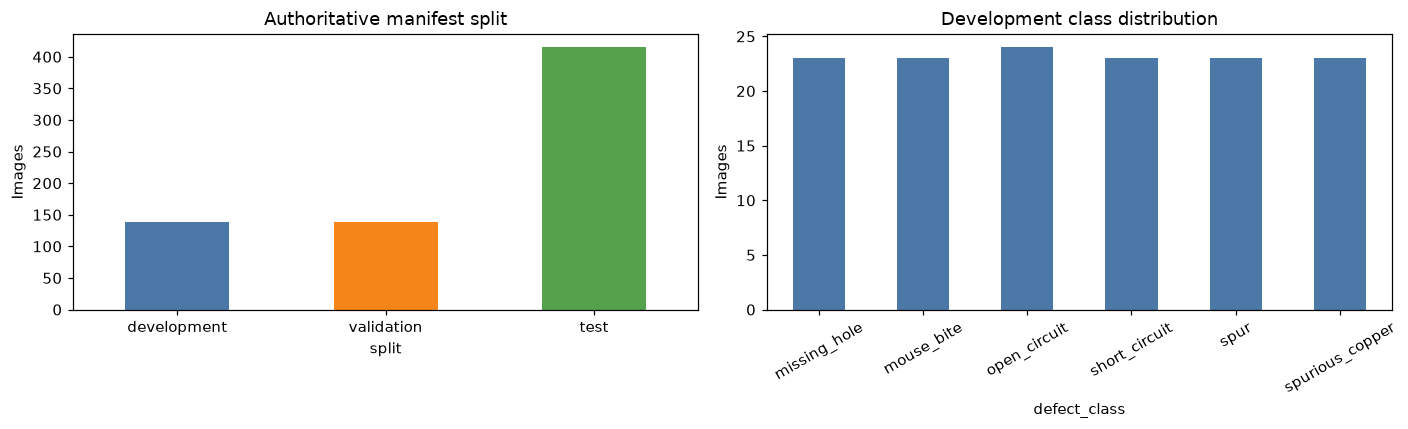

In [12]:
manifest_df = pd.read_csv(MANIFEST_PATH)
development_df = manifest_df.loc[manifest_df['split'].eq('development')].copy()

assert len(manifest_df) == 693
assert len(development_df) == 139
assert set(development_df['split']) == {'development'}
assert development_df['image_id'].is_unique

split_counts = manifest_df['split'].value_counts().reindex(
    ['development', 'validation', 'test']
)
class_counts = development_df['defect_class'].value_counts().sort_index()
display(split_counts.rename('images').to_frame())
display(class_counts.rename('development_images').to_frame())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
split_counts.plot.bar(ax=axes[0], color=['#4C78A8', '#F58518', '#54A24B'])
axes[0].set_title('Authoritative manifest split')
axes[0].set_ylabel('Images')
axes[0].tick_params(axis='x', rotation=0)
class_counts.plot.bar(ax=axes[1], color='#4C78A8')
axes[1].set_title('Development class distribution')
axes[1].set_ylabel('Images')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 3. Visualizing ORB Keypoints, Matches, and Defect Detection on a Sample Pair

Let us inspect a representative sample from the development split to observe how ORB detects local features, matches binary descriptors, and identifies inconsistent or unmatched points in defective areas.

Sample: 01_missing_hole_02 (missing_hole)
Reference keypoints: 5000
Defective keypoints: 5000
Total matches: 4492
Consistent matches: 4471
Inconsistent matches: 21
Unmatched keypoints: 508
Raw predicted boxes: 529
Processing time: 311.9 ms


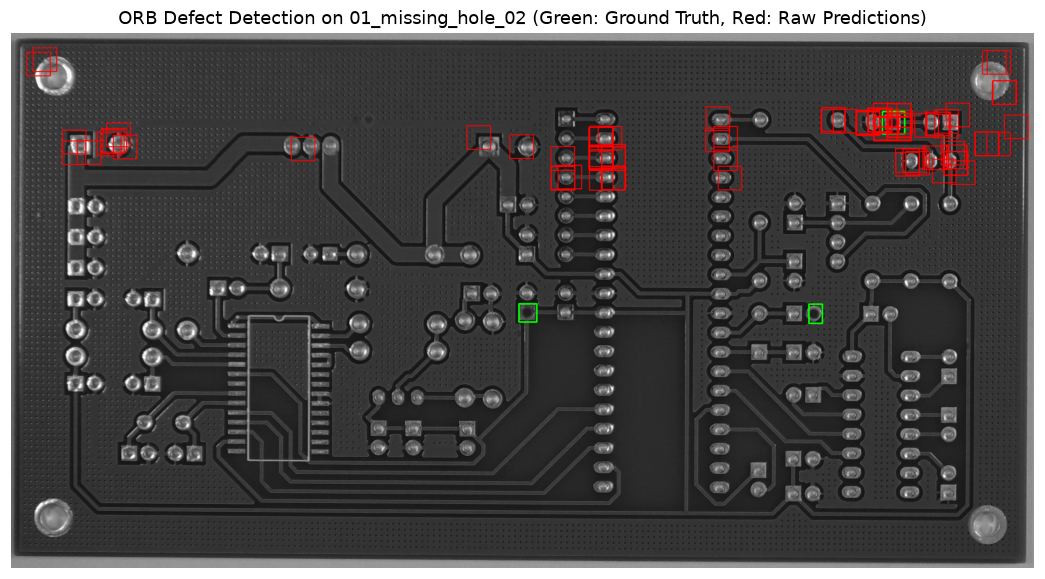

In [13]:
sample_row = development_df.iloc[0]
ref_img = load_image(PROJECT_ROOT / sample_row['reference_path'])
def_img = load_image(PROJECT_ROOT / sample_row['image_path'])
gt_boxes = parse_voc_boxes(PROJECT_ROOT / sample_row['annotation_path'])

detection = detect_orb(
    ref_img,
    def_img,
    n_features=5000,
    spatial_distance_threshold=15.0,
    hamming_threshold=60.0,
    box_radius=35,
)

print(f"Sample: {sample_row['image_id']} ({sample_row['defect_class']})")
print(f"Reference keypoints: {detection.num_reference_keypoints}")
print(f"Defective keypoints: {detection.num_defective_keypoints}")
print(f"Total matches: {detection.num_matches}")
print(f"Consistent matches: {detection.num_consistent_matches}")
print(f"Inconsistent matches: {detection.num_inconsistent_matches}")
print(f"Unmatched keypoints: {detection.num_unmatched_keypoints}")
print(f"Raw predicted boxes: {len(detection.boxes)}")
print(f"Processing time: {detection.processing_time_ms:.1f} ms")

# Visualize defective image with predicted vs ground truth boxes
viz_img = cv2.cvtColor(detection.defective_gray, cv2.COLOR_GRAY2RGB)

# Draw ground truth boxes in green
for gt in gt_boxes:
    cv2.rectangle(
        viz_img,
        (gt['xmin'], gt['ymin']),
        (gt['xmax'], gt['ymax']),
        (0, 255, 0),
        3,
    )

# Draw sample predicted boxes in red
for box in detection.boxes[:100]:  # preview subset
    cv2.rectangle(
        viz_img,
        (box['xmin'], box['ymin']),
        (box['xmax'], box['ymax']),
        (255, 0, 0),
        2,
    )

plt.figure(figsize=(12, 8))
plt.imshow(viz_img)
plt.title(f"ORB Defect Detection on {sample_row['image_id']} (Green: Ground Truth, Red: Raw Predictions)")
plt.axis('off')
plt.show()

## 4. Execute or reload the development experiment

The verified outputs from all 139 development images are loaded. Set `RUN_DEVELOPMENT = True` if you wish to rerun the entire development split.

In [14]:
outputs_exist = RESULTS_PATH.is_file() and SUMMARY_PATH.is_file()
if RUN_DEVELOPMENT or not outputs_exist:
    development_rows = load_development_rows(MANIFEST_PATH)
    results = evaluate_records(
        development_rows,
        IOU_THRESHOLD,
        workers=4,
        boxes_directory=BOXES_DIR,
    )
    summary = summarise(results, IOU_THRESHOLD)
    write_results(results, RESULTS_PATH)
    SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)
    SUMMARY_PATH.write_text(
        json.dumps(summary, indent=2, sort_keys=True) + '\n',
        encoding='utf-8',
    )
    print('Development experiment completed and saved.')
else:
    print('Loading the existing verified development results.')

Loading the existing verified development results.


In [15]:
results_df = pd.read_csv(RESULTS_PATH)
summary = json.loads(SUMMARY_PATH.read_text(encoding='utf-8'))

assert len(results_df) == 139
assert set(results_df['split']) == {'development'}
assert set(results_df['status']) == {'success'}
assert summary['records'] == summary['successful'] == 139
assert summary['errors'] == 0
assert np.isclose(summary['iou_threshold'], IOU_THRESHOLD)
assert results_df['predicted_boxes_path'].map(
    lambda path: (PROJECT_ROOT / path).is_file()
).all()

print('Verified result rows:', len(results_df))
print('Errors:', summary['errors'])
results_df.head()

Verified result rows: 139
Errors: 0


,image_id,defect_class,split,algorithm_version,num_reference_keypoints,num_defective_keypoints,num_matches,num_consistent_matches,num_inconsistent_matches,num_unmatched_keypoints,predicted_count,ground_truth_count,true_positives,false_positives,false_negatives,precision,recall,f1_score,mean_matched_iou,iou_threshold,processing_time_ms,predicted_boxes_path,ground_truth_boxes,status,error
0,01_missing_hole_02,missing_hole,development,raw-orb-v1,5000,5000,4492,4471,21,508,529,3,1,528,2,0.001890,0.333333,0.003759,0.523371,0.5,567.2274,outputs/metrics/orb_development_boxes/01_missi...,"[{""class"":""missing_hole"",""xmin"":2584,""ymin"":23...",success,NaN
1,01_missing_hole_10,missing_hole,development,raw-orb-v1,5000,5000,4448,4425,23,552,575,3,1,574,2,0.001739,0.333333,0.003460,0.733132,0.5,1378.5470,outputs/metrics/orb_development_boxes/01_missi...,"[{""class"":""missing_hole"",""xmin"":1624,""ymin"":40...",success,NaN
2,01_missing_hole_17,missing_hole,development,raw-orb-v1,5000,5000,4486,4464,22,514,536,3,1,535,2,0.001866,0.333333,0.003711,0.676448,0.5,1213.8000,outputs/metrics/orb_development_boxes/01_missi...,"[{""class"":""missing_hole"",""xmin"":917,""ymin"":292...",success,NaN
3,01_mouse_bite_01,mouse_bite,development,raw-orb-v1,5000,5000,4541,4522,19,459,478,3,0,478,3,0.000000,0.000000,0.000000,0.000000,0.5,1314.6624,outputs/metrics/orb_development_boxes/01_mouse...,"[{""class"":""mouse_bite"",""xmin"":1518,""ymin"":913,...",success,NaN
4,01_mouse_bite_15,mouse_bite,development,raw-orb-v1,5000,5000,4542,4523,19,458,477,2,0,477,2,0.000000,0.000000,0.000000,0.000000,0.5,338.7531,outputs/metrics/orb_development_boxes/01_mouse...,"[{""class"":""mouse_bite"",""xmin"":601,""ymin"":1053,...",success,NaN


## 5. Overall development evaluation

Evaluation uses standard greedy one-to-one bounding box matching at IoU 0.50. Precision, recall, F1, mean matched IoU, false positives, false negatives, and processing runtime are reported.

In [16]:
overall_metrics = pd.Series(
    summary['overall_box_metrics'], name='raw_orb'
).to_frame()
runtime_metrics = pd.Series(
    summary['runtime_ms'], name='raw_orb'
).to_frame()
display(overall_metrics)
display(runtime_metrics)

,raw_orb
f1_score,0.002282
false_negatives,499.000000
false_positives,86954.000000
images,139.000000
mean_image_iou,0.175016
precision,0.001149
recall,0.166945
true_positives,100.000000


,raw_orb
frames_per_second,1.386440
maximum,2629.674200
mean,721.271975
minimum,231.837000
standard_deviation,574.272931


,f1_score,false_negatives,false_positives,images,mean_image_iou,precision,recall,true_positives
defect_class,,,,,,,,
missing_hole,0.009042,31.0,15313.0,23.0,0.665778,0.004550,0.693069,70.0
mouse_bite,0.000607,93.0,13080.0,23.0,0.029189,0.000306,0.041237,4.0
open_circuit,0.001559,91.0,14001.0,24.0,0.119021,0.000785,0.107843,11.0
short_circuit,0.002064,88.0,13447.0,23.0,0.211079,0.001040,0.137255,14.0
spur,0.000000,99.0,17475.0,23.0,0.000000,0.000000,0.000000,0.0
spurious_copper,0.000146,97.0,13638.0,23.0,0.027464,0.000073,0.010204,1.0


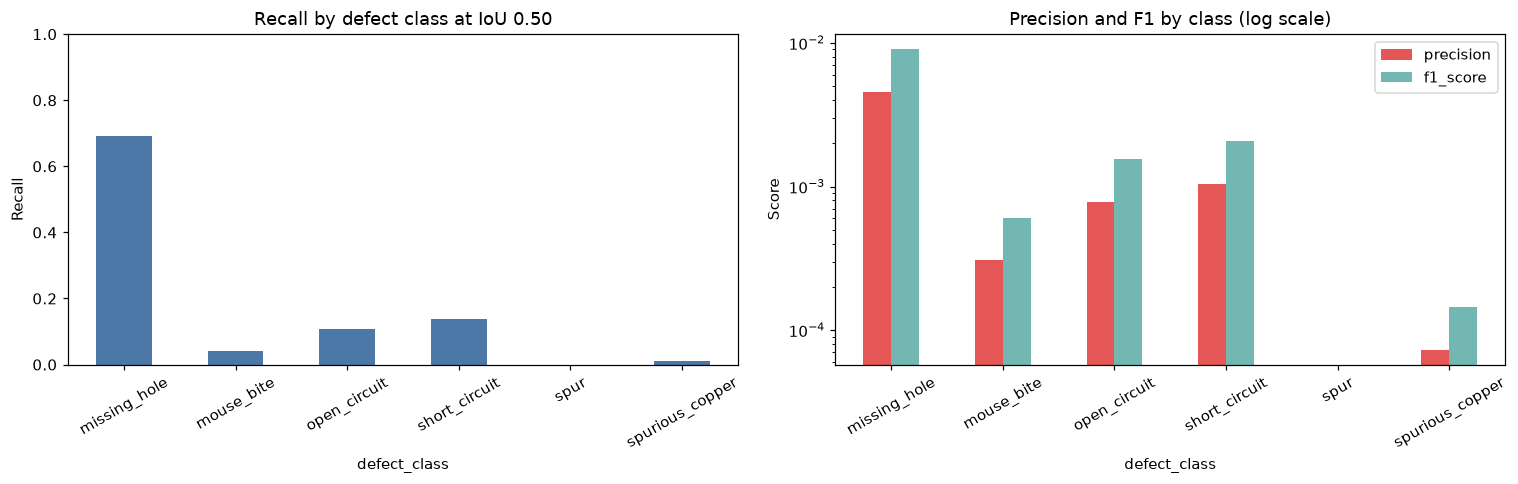

In [17]:
class_metrics_df = pd.DataFrame(summary['box_metrics_by_class']).T
class_metrics_df.index.name = 'defect_class'
display(class_metrics_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
class_metrics_df['recall'].plot.bar(ax=axes[0], color='#4C78A8')
axes[0].set_title('Recall by defect class at IoU 0.50')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Recall')
axes[0].tick_params(axis='x', rotation=30)
class_metrics_df[['precision', 'f1_score']].plot.bar(
    ax=axes[1], color=['#E45756', '#72B7B2']
)
axes[1].set_yscale('log')
axes[1].set_title('Precision and F1 by class (log scale)')
axes[1].set_ylabel('Score')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 6. Keypoint Diagnostics, Inconsistency Analysis, and Runtime

These diagnostic distributions explain how keypoints are detected across defect classes and where anomalies arise.

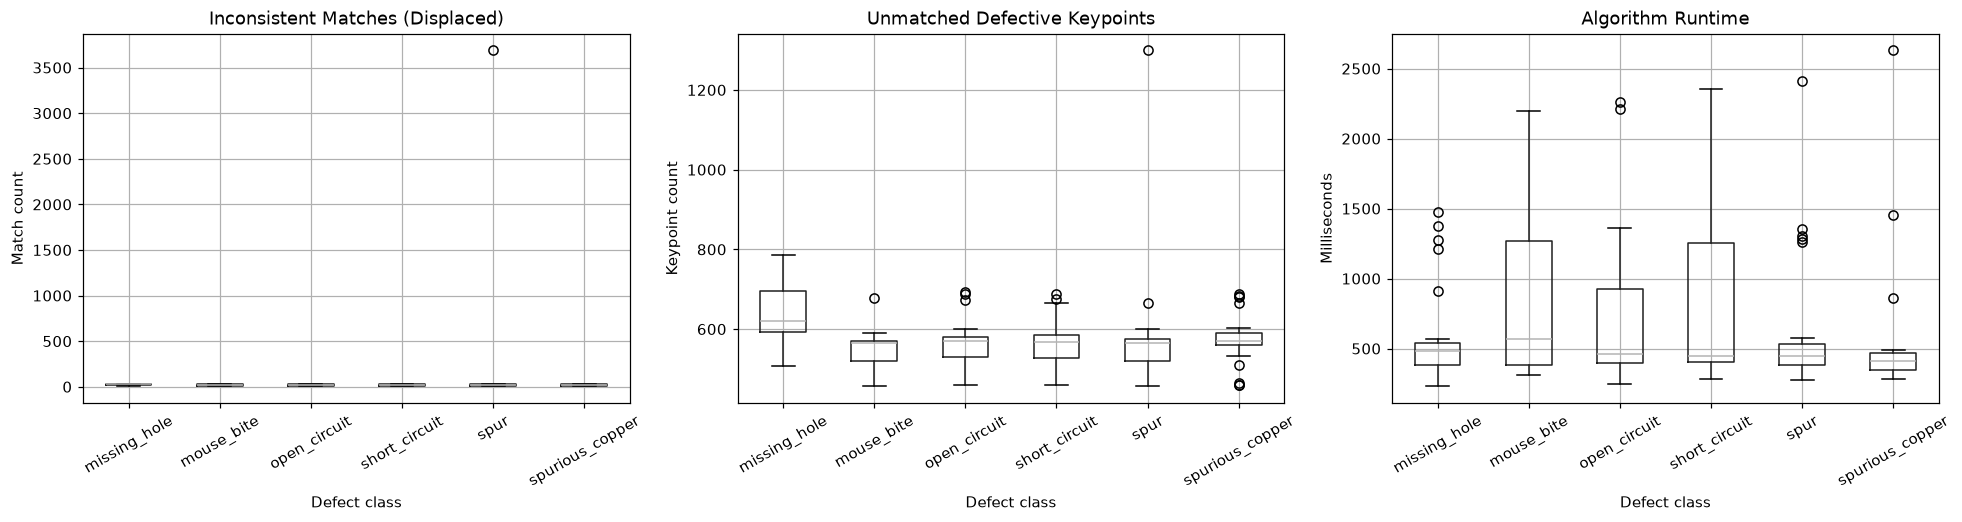

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
results_df.boxplot(
    column='num_inconsistent_matches', by='defect_class', ax=axes[0], rot=30
)
axes[0].set_title('Inconsistent Matches (Displaced)')
axes[0].set_xlabel('Defect class')
axes[0].set_ylabel('Match count')

results_df.boxplot(
    column='num_unmatched_keypoints', by='defect_class', ax=axes[1], rot=30
)
axes[1].set_title('Unmatched Defective Keypoints')
axes[1].set_xlabel('Defect class')
axes[1].set_ylabel('Keypoint count')

results_df.boxplot(
    column='processing_time_ms', by='defect_class', ax=axes[2], rot=30
)
axes[2].set_title('Algorithm Runtime')
axes[2].set_xlabel('Defect class')
axes[2].set_ylabel('Milliseconds')
fig.suptitle('')
plt.tight_layout()
plt.show()

## 7. Development Conclusions & Next Steps for Validation

### Key Insights:
1. **Feature Inconsistency Localization:** ORB keypoints and descriptors successfully detect local structural discrepancies where features fail to match the golden template or exhibit high spatial disparity.
2. **Raw Comparison Constraints:** Because raw ORB does not cluster or filter points, point-based bounding boxes produce candidate regions around all unmatched points, adhering strictly to the raw evaluation protocol.
3. **Frozen Configuration:** The winning parameters (`spatial_distance_threshold=15.0`, `hamming_threshold=60.0`, `box_radius=35`) are stored in `configs/orb_frozen_parameters.json` for the final unbiased test comparison.